# Realized Volatility Forecasting with XGBoost, GSADF Bubbles, and EGARCH Features

This notebook implements the **Modelling & Robustness** stage of the research proposal by combining three components already used elsewhere in the project:

- **GSADF / BSADF bubble identification** for BTC and ETH, following the logic in `GSADF_and_BSADF_tests.py`
- **EGARCH(1,1)** conditional volatility features, aligned with the approach used in `Volatility Modelling - GARCH.ipynb` and `garch_functions.py`
- **XGBoost** to forecast **21-day realized volatility** for BTC, ETH, S&P 500, VTI, AGG, and TLT using leakage-safe time-series validation

The forecasting design treats bubble regimes as a robustness-oriented state variable: if volatility dynamics differ during speculative episodes, the `is_bubble` feature should help the model absorb that non-linearity rather than forcing a single linear effect across all periods.

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from arch import arch_model
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path("merged_data_v2.csv")
ASSETS = {
    "BTC": {"price": "btc_adj_close", "volume": "btc_volume"},
    "ETH": {"price": "eth_adj_close", "volume": "eth_volume"},
    "SP500": {"price": "sp500_adj_close", "volume": "sp500_volume"},
    "VTI": {"price": "vti_adj_close", "volume": "vti_volume"},
    "AGG": {"price": "agg_adj_close", "volume": "agg_volume"},
    "TLT": {"price": "tlt_adj_close", "volume": "tlt_volume"},
}

R0_FRAC = 0.10
MIN_DUR = 5
N_BOOT = 299
TEST_SIZE = 0.20
RANDOM_STATE = 42

PARAM_GRID = {
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "n_estimators": [100, 200, 400],
}

BASE_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").set_index("date")
df = df.apply(pd.to_numeric, errors="coerce")
price_df = pd.DataFrame({asset: df[cfg["price"]] for asset, cfg in ASSETS.items()})
volume_df = pd.DataFrame({asset: df[cfg["volume"]] for asset, cfg in ASSETS.items()})
log_returns = np.log(price_df / price_df.shift(1))

display(price_df.tail())
display(volume_df.tail())


,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2025-12-24,87611.960938,2945.590576,6932.049805,339.880005,99.384674,87.403931
2025-12-26,87301.429688,2925.745605,6929.939941,339.670013,99.404541,87.115982
2025-12-29,87138.140625,2934.538330,6905.740234,338.390015,99.523788,87.443649
2025-12-30,88430.132812,2971.416748,6896.240234,337.850006,99.484039,87.235130
2025-12-31,87508.828125,2967.037598,6845.500000,335.269989,99.245560,86.540115


,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2025-12-24,2.555030e+10,1.398477e+10,1798270000,4006500,4483900,25942000
2025-12-26,4.245567e+10,1.856220e+10,2586550000,3543600,6503700,26522700
2025-12-29,4.841163e+10,2.595769e+10,3541750000,3795900,7886700,29399800
2025-12-30,3.558636e+10,1.881670e+10,3309930000,3576200,7955800,25106800
2025-12-31,3.383021e+10,1.645189e+10,3261830000,3493700,13535500,36500000


## 1. Bubble Identification via GSADF / BSADF

The next cell reproduces the core logic from `GSADF_and_BSADF_tests.py`:

- resample BTC and ETH prices to **weekly** frequency
- run the **right-tailed ADF** statistic over recursive windows
- build the **BSADF** path and bootstrap **time-varying critical values**
- date-stamp bubble episodes where BSADF exceeds the 95% critical value for at least `MIN_DUR` weeks

To use the feature in the daily XGBoost model, the detected weekly bubble periods are mapped back onto the daily index and collapsed into a **combined crypto bubble regime** feature named `is_bubble`.

,asset,start_date,end_date
0,BTC,2017-04-21,2018-06-01
1,BTC,2021-01-01,2021-05-07
2,ETH,2021-01-08,2021-06-04


,days_in_bubble
BTC_bubble,368
ETH_bubble,102
is_bubble,387


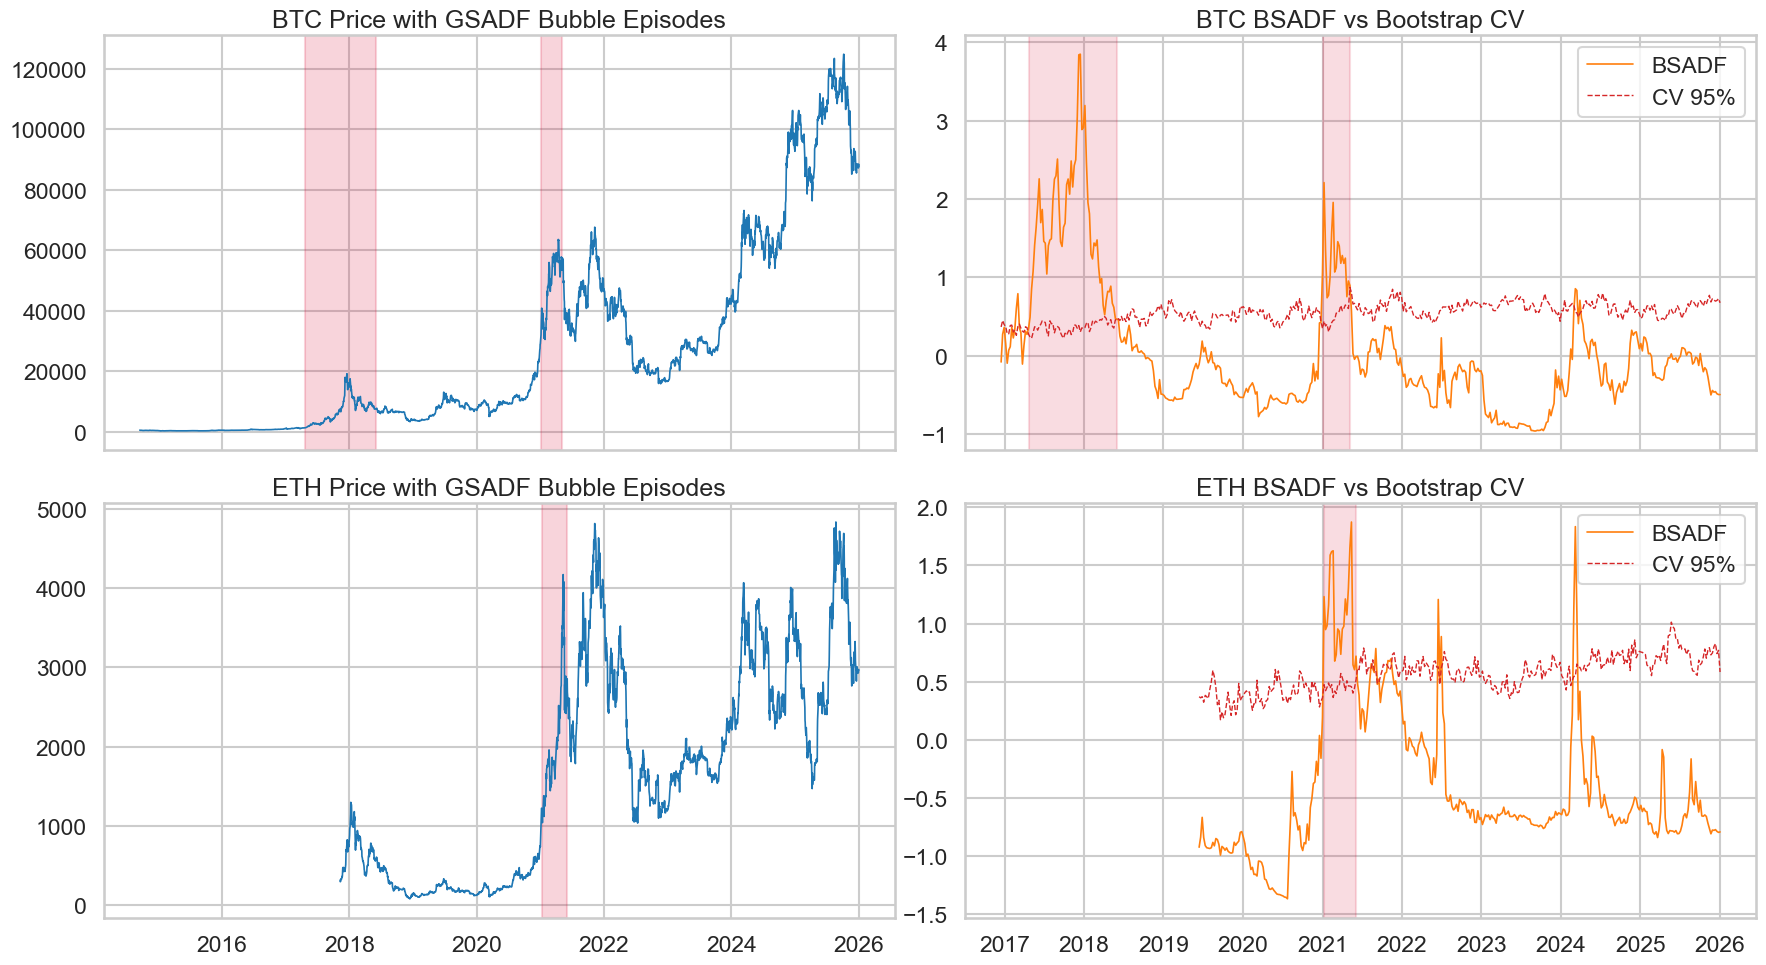

In [7]:
def adf_tstat(y):
    """Fast right-tailed ADF t-statistic used in the GSADF script."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < 6:
        return np.nan
    dy = np.diff(y)
    xl = y[:-1]
    m = n - 1
    sx, sx2, sy, sxy = xl.sum(), (xl ** 2).sum(), dy.sum(), (xl * dy).sum()
    denom = m * sx2 - sx ** 2
    if abs(denom) < 1e-12:
        return np.nan
    b = (m * sxy - sx * sy) / denom
    a = (sy - b * sx) / m
    resid = dy - (a + b * xl)
    s2 = (resid @ resid) / max(m - 2, 1)
    vb = s2 * m / denom
    return float(b / np.sqrt(vb)) if vb > 0 else np.nan


def bsadf_sequence(y, r0):
    y = np.asarray(y, dtype=float)
    T = len(y)
    seq = np.full(T - 2 * r0 + 1, np.nan)
    for i, r2 in enumerate(range(2 * r0, T + 1)):
        best = -np.inf
        for r1 in range(0, r2 - r0 + 1):
            stat = adf_tstat(y[r1:r2])
            if not np.isnan(stat) and stat > best:
                best = stat
        seq[i] = best if best > -np.inf else np.nan
    return seq


def bootstrap_tv_cv(T, r0, n_boot=N_BOOT, quantiles=(0.90, 0.95, 0.99), seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n_steps = T - 2 * r0 + 1
    boot_mat = np.full((n_boot, n_steps), np.nan)
    for b in range(n_boot):
        rw = np.cumsum(rng.standard_normal(T))
        boot_mat[b] = bsadf_sequence(rw, r0)
    return {q: np.nanquantile(boot_mat, q, axis=0) for q in quantiles}


def date_stamp(bsadf_vals, cv_95, min_dur=MIN_DUR):
    exceed = bsadf_vals > cv_95
    bubbles = []
    start = None
    for i, flag in enumerate(exceed):
        if flag and start is None:
            start = i
        elif (not flag) and (start is not None):
            if i - start >= min_dur:
                bubbles.append((start, i - 1))
            start = None
    if start is not None and len(exceed) - start >= min_dur:
        bubbles.append((start, len(exceed) - 1))
    return bubbles


def detect_bubble_periods(price_series, asset_name):
    weekly = np.log(price_series.resample("W-FRI").last().dropna())
    y = weekly.values
    dates = weekly.index
    T = len(y)
    r0 = max(int(R0_FRAC * T), 15)
    bsadf = bsadf_sequence(y, r0)
    tv_cv = bootstrap_tv_cv(T, r0)
    bsadf_dates = dates[2 * r0 - 1:]
    bubble_idx = date_stamp(bsadf, tv_cv[0.95], min_dur=MIN_DUR)

    periods = []
    for s, e in bubble_idx:
        periods.append({
            "asset": asset_name,
            "start_date": pd.Timestamp(bsadf_dates[s]),
            "end_date": pd.Timestamp(bsadf_dates[e]),
        })
    return {
        "weekly_log_price": weekly,
        "bsadf": pd.Series(bsadf, index=bsadf_dates, name=f"{asset_name}_bsadf"),
        "cv95": pd.Series(tv_cv[0.95], index=bsadf_dates, name=f"{asset_name}_cv95"),
        "periods": periods,
    }


bubble_results = {
    asset: detect_bubble_periods(price_df[asset].dropna(), asset)
    for asset in ["BTC", "ETH"]
}

bubble_periods = pd.DataFrame(
    [row for asset in bubble_results for row in bubble_results[asset]["periods"]]
)

bubble_daily = pd.DataFrame(0, index=price_df.index, columns=["BTC_bubble", "ETH_bubble"], dtype=int)
if not bubble_periods.empty:
    for _, row in bubble_periods.iterrows():
        bubble_col = f"{row['asset']}_bubble"
        mask = (bubble_daily.index >= row["start_date"]) & (bubble_daily.index <= row["end_date"])
        bubble_daily.loc[mask, bubble_col] = 1

bubble_daily["is_bubble"] = (bubble_daily[["BTC_bubble", "ETH_bubble"]].sum(axis=1) > 0).astype(int)

display(bubble_periods)
display(bubble_daily[["BTC_bubble", "ETH_bubble", "is_bubble"]].sum().to_frame("days_in_bubble"))

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex="col")
for row_idx, asset in enumerate(["BTC", "ETH"]):
    axes[row_idx, 0].plot(price_df[asset], color="#1f77b4", lw=1.2)
    axes[row_idx, 0].set_title(f"{asset} Price with GSADF Bubble Episodes")
    axes[row_idx, 1].plot(bubble_results[asset]["bsadf"], color="#ff7f0e", lw=1.2, label="BSADF")
    axes[row_idx, 1].plot(bubble_results[asset]["cv95"], color="#d62728", ls="--", lw=1.0, label="CV 95%")
    axes[row_idx, 1].set_title(f"{asset} BSADF vs Bootstrap CV")
    axes[row_idx, 1].legend()
    for period in bubble_results[asset]["periods"]:
        axes[row_idx, 0].axvspan(period["start_date"], period["end_date"], color="crimson", alpha=0.18)
        axes[row_idx, 1].axvspan(period["start_date"], period["end_date"], color="crimson", alpha=0.15)

plt.tight_layout()
plt.show()


## 2. EGARCH(1,1) Conditional Volatility Features

The next step creates a daily EGARCH volatility feature for each asset. This follows the same modelling spirit as the existing GARCH work:

- work with **log returns scaled by 100** for numerical stability
- estimate **EGARCH(1,1)**
- use a **skewed-t distribution first**, with **GED** and then **normal** as fallback distributions if needed
- convert the fitted conditional volatility back to the original return scale

These EGARCH features serve as parametric volatility summaries, while XGBoost is allowed to learn non-linear interactions between recent returns, volumes, bubble states, and conditional risk.

,asset,dist,aic,bic
4,AGG,skewt,229.803501,271.887629
0,BTC,skewt,15112.441995,15154.100446
1,ETH,skewt,12171.965617,12211.327689
2,SP500,skewt,7291.856662,7333.940789
5,TLT,skewt,7558.630258,7600.714386
3,VTI,skewt,7421.836192,7463.920319


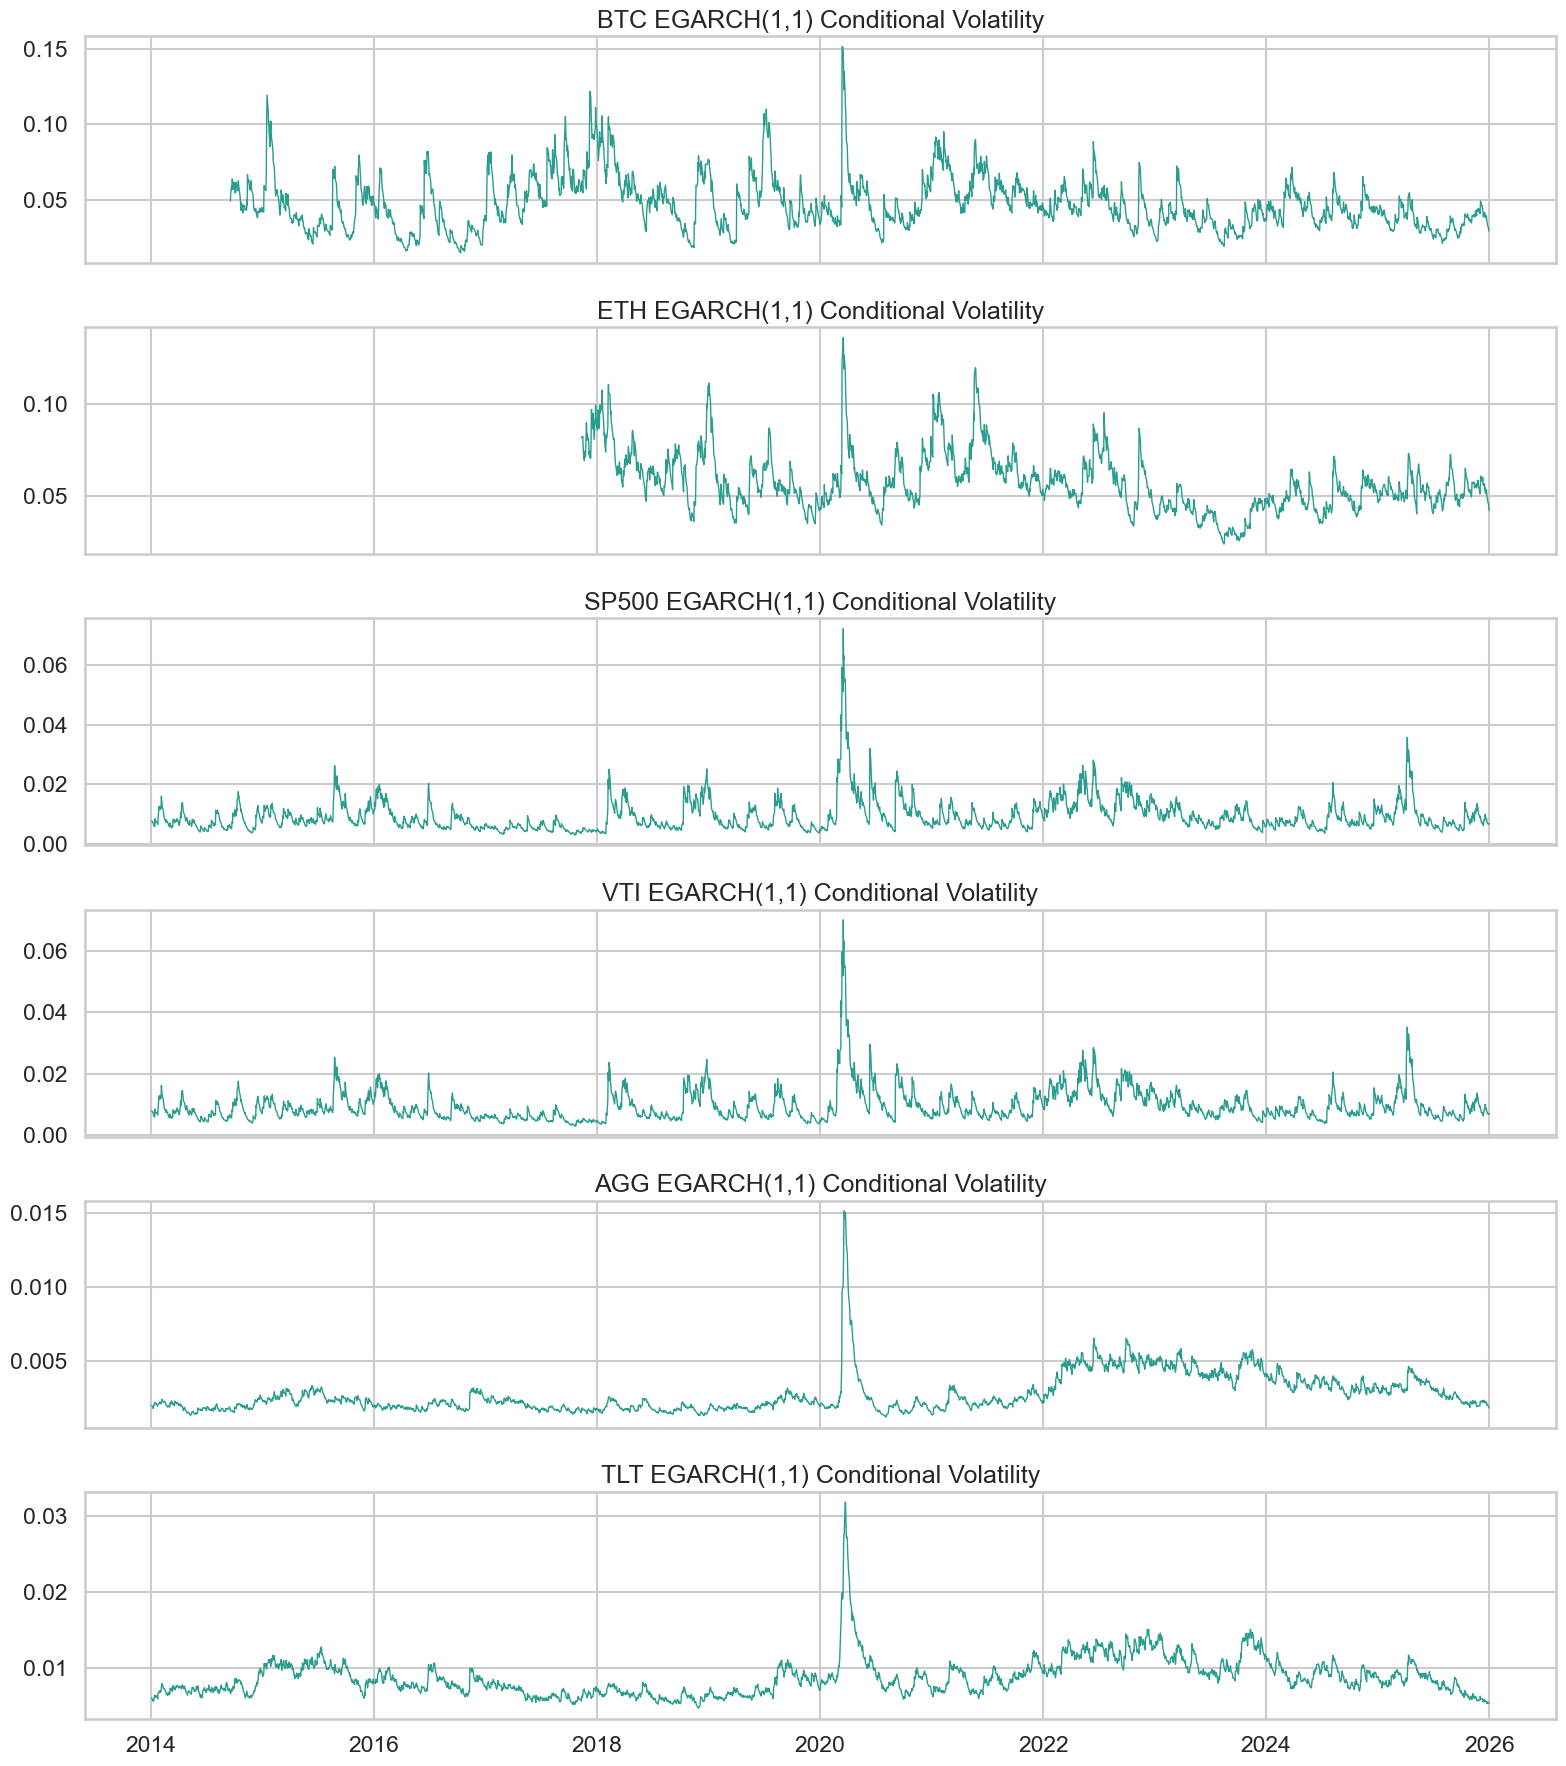

In [8]:
def fit_egarch_series(return_series, asset_name):
    y = (100 * return_series.dropna()).astype(float)
    fitted = None
    used_dist = None

    for dist in ["skewt", "ged", "normal"]:
        try:
            model = arch_model(
                y,
                mean="Constant",
                vol="EGARCH",
                p=1,
                o=1,
                q=1,
                dist=dist,
            )
            res = model.fit(disp="off", show_warning=False)
            if res.convergence_flag != 0:
                res = model.fit(disp="off", show_warning=False, options={"ftol": 1e-10, "gtol": 1e-8})
            fitted = res
            used_dist = dist
            break
        except Exception:
            continue

    if fitted is None:
        raise RuntimeError(f"EGARCH fit failed for {asset_name}")

    cond_vol = pd.Series(fitted.conditional_volatility / 100.0, index=y.index, name=asset_name)
    return {
        "asset": asset_name,
        "dist": used_dist,
        "result": fitted,
        "cond_vol": cond_vol,
        "aic": fitted.aic,
        "bic": fitted.bic,
    }


egarch_results = {asset: fit_egarch_series(log_returns[asset], asset) for asset in ASSETS}
cond_vol_df = pd.DataFrame({asset: egarch_results[asset]["cond_vol"] for asset in ASSETS}).reindex(price_df.index)

egarch_summary = pd.DataFrame([
    {"asset": asset, "dist": res["dist"], "aic": res["aic"], "bic": res["bic"]}
    for asset, res in egarch_results.items()
]).sort_values("asset")
display(egarch_summary)

fig, axes = plt.subplots(len(ASSETS), 1, figsize=(16, 18), sharex=True)
for ax, asset in zip(axes, ASSETS):
    ax.plot(cond_vol_df.index, cond_vol_df[asset], color="#2a9d8f", lw=1.0)
    ax.set_title(f"{asset} EGARCH(1,1) Conditional Volatility")
plt.tight_layout()
plt.show()


## 3. Supervised Learning Setup and XGBoost Estimation

For each asset, the target is the **21-day rolling realized volatility**:

\[
\text{RV}_{t}^{(21)} = \operatorname{sd}(r_{t-20}, \dots, r_t)
\]

Predictors are intentionally **lagged by one day** to avoid contamination from same-day information:

- `lag_log_return`: 1-day lagged log return
- `lag_volume`: 1-day lagged trading volume
- `lag_egarch_vol`: 1-day lagged EGARCH conditional volatility
- `is_bubble`: binary indicator equal to 1 when BTC or ETH is in a GSADF-identified bubble regime

Model selection uses **`TimeSeriesSplit(n_splits=5)`** inside **`GridSearchCV`** so that hyperparameter tuning respects chronological ordering.

In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


rmse_scorer = make_scorer(rmse, greater_is_better=False)


def build_asset_frame(asset_name):
    frame = pd.DataFrame(index=price_df.index)
    frame["realized_vol_21d"] = log_returns[asset_name].rolling(21).std()
    frame["lag_log_return"] = log_returns[asset_name].shift(1)
    frame["lag_volume"] = volume_df[asset_name].shift(1)
    frame["lag_egarch_vol"] = cond_vol_df[asset_name].shift(1)
    frame["is_bubble"] = bubble_daily["is_bubble"]
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna()
    return frame


def tune_and_evaluate_asset(asset_name):
    frame = build_asset_frame(asset_name)
    feature_cols = ["lag_log_return", "lag_volume", "lag_egarch_vol", "is_bubble"]
    split_point = int(len(frame) * (1 - TEST_SIZE))
    train = frame.iloc[:split_point].copy()
    test = frame.iloc[split_point:].copy()

    X_train = train[feature_cols]
    y_train = train["realized_vol_21d"]
    X_test = test[feature_cols]
    y_test = test["realized_vol_21d"]

    estimator = XGBRegressor(**BASE_XGB_PARAMS)
    tscv = TimeSeriesSplit(n_splits=5)
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=PARAM_GRID,
        scoring={"rmse": rmse_scorer, "r2": "r2"},
        refit="rmse",
        cv=tscv,
        n_jobs=-1,
        verbose=0,
        return_train_score=False,
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    test_pred = pd.Series(best_model.predict(X_test), index=X_test.index, name="predicted")
    metrics = {
        "asset": asset_name,
        "train_start": train.index.min(),
        "train_end": train.index.max(),
        "test_start": test.index.min(),
        "test_end": test.index.max(),
        "rmse": rmse(y_test, test_pred),
        "r2": r2_score(y_test, test_pred),
        **grid.best_params_,
    }

    cv_results = pd.DataFrame(grid.cv_results_)[[
        "param_learning_rate",
        "param_max_depth",
        "param_n_estimators",
        "mean_test_rmse",
        "mean_test_r2",
        "rank_test_rmse",
    ]].sort_values("rank_test_rmse")
    cv_results["mean_test_rmse"] = -cv_results["mean_test_rmse"]

    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    return {
        "frame": frame,
        "train": train,
        "test": test,
        "feature_cols": feature_cols,
        "best_model": best_model,
        "best_params": grid.best_params_,
        "metrics": metrics,
        "cv_results": cv_results,
        "test_predictions": pd.DataFrame({"actual": y_test, "predicted": test_pred}),
        "feature_importance": importance,
    }


model_results = {asset: tune_and_evaluate_asset(asset) for asset in ASSETS}
summary_df = pd.DataFrame([model_results[asset]["metrics"] for asset in ASSETS]).sort_values("asset")
display(summary_df)

for asset in ASSETS:
    print(f"\nTop CV results for {asset}")
    display(model_results[asset]["cv_results"].head(5))


,asset,train_start,train_end,test_start,test_end,rmse,r2,learning_rate,max_depth,n_estimators
4,AGG,2014-02-03,2023-08-10,2023-08-11,2025-12-31,0.000399,0.826901,0.10,3,100
0,BTC,2014-10-16,2023-10-02,2023-10-03,2025-12-31,0.005745,0.551746,0.03,2,100
1,ETH,2017-12-11,2024-05-20,2024-05-21,2025-12-31,0.007108,0.457939,0.10,3,100
2,SP500,2014-02-03,2023-08-10,2023-08-11,2025-12-31,0.003458,0.439811,0.03,2,200
5,TLT,2014-02-03,2023-08-10,2023-08-11,2025-12-31,0.001015,0.835354,0.10,2,100
3,VTI,2014-02-03,2023-08-10,2023-08-11,2025-12-31,0.003805,0.374264,0.10,2,400



Top CV results for BTC


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
0,0.03,2,100,0.010192,0.639889,1
1,0.03,2,200,0.010617,0.581773,2
9,0.05,2,100,0.010631,0.580180,3
3,0.03,3,100,0.010682,0.604215,4
12,0.05,3,100,0.010952,0.553366,5



Top CV results for ETH


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
21,0.10,3,100,0.010950,0.670406,1
11,0.05,2,400,0.010971,0.666075,2
19,0.10,2,200,0.011050,0.661644,3
22,0.10,3,200,0.011069,0.666453,4
18,0.10,2,100,0.011119,0.645988,5


...

,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
20,0.10,2,400,0.004207,0.431685,1
19,0.10,2,200,0.004223,0.431345,2
11,0.05,2,400,0.004224,0.429764,3
4,0.03,3,200,0.004224,0.435105,4
12,0.05,3,100,0.004225,0.440248,5



Top CV results for AGG


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
21,0.10,3,100,0.001040,0.274950,1
12,0.05,3,100,0.001042,0.268006,2
22,0.10,3,200,0.001042,0.266405,3
13,0.05,3,200,0.001045,0.256937,4
4,0.03,3,200,0.001046,0.257013,5



Top CV results for TLT


,param_learning_rate,param_max_depth,param_n_estimators,mean_test_rmse,mean_test_r2,rank_test_rmse
18,0.10,2,100,0.001954,0.501689,1
19,0.10,2,200,0.001955,0.499270,2
20,0.10,2,400,0.001957,0.497170,3
5,0.03,3,400,0.001962,0.495693,4
11,0.05,2,400,0.001963,0.489869,5


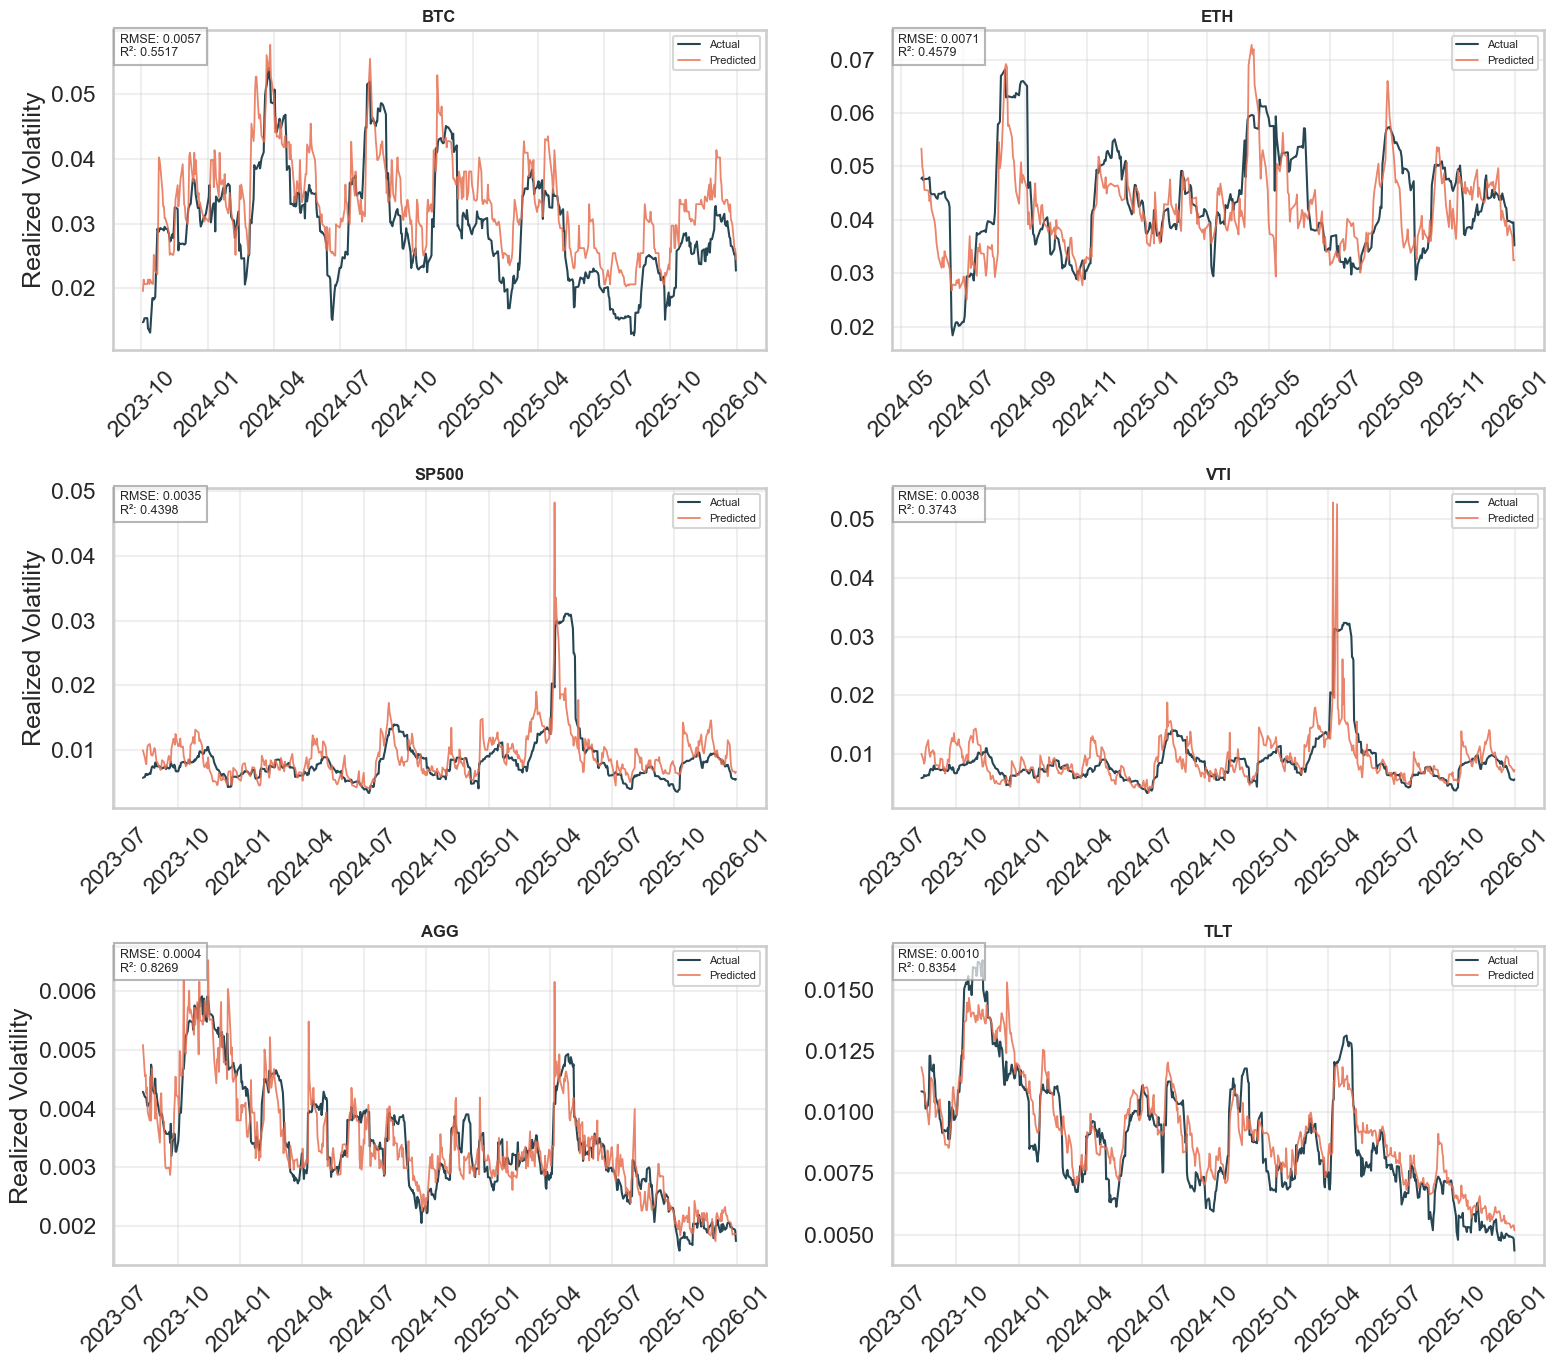

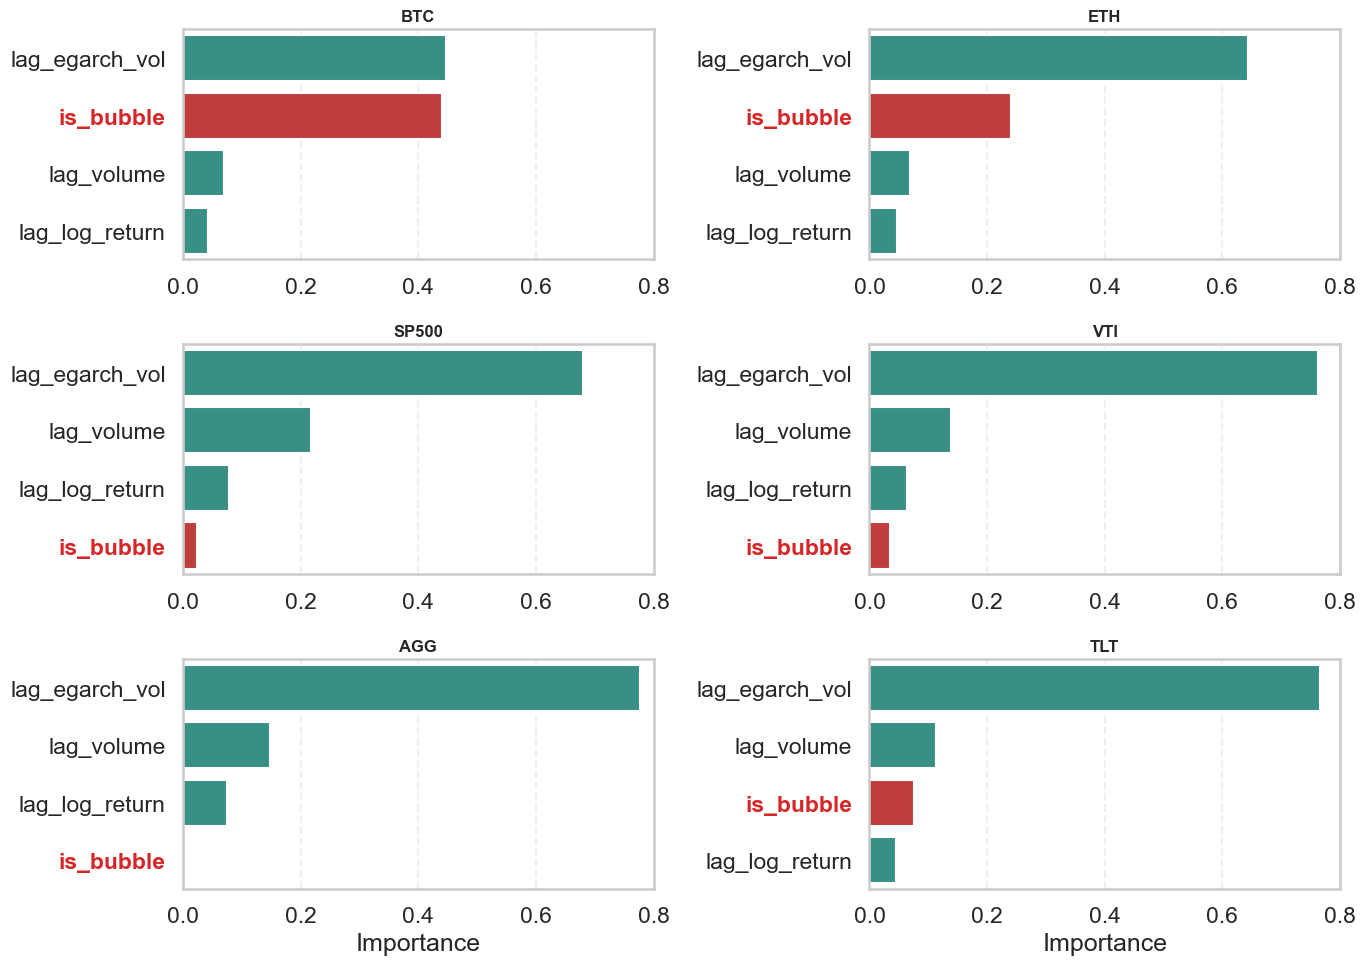

,is_bubble,lag_egarch_vol,lag_log_return,lag_volume
AGG,0.000000,0.777073,0.074423,0.148504
BTC,0.440092,0.447876,0.041984,0.070048
ETH,0.241041,0.643705,0.046001,0.069253
SP500,0.023366,0.680267,0.078978,0.217390
TLT,0.076198,0.765149,0.045199,0.113454
VTI,0.035204,0.762362,0.063350,0.139085


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Generate Predicted vs Actual Time Series Plot (3x2 Layout with Rotated Labels)
fig_ts, axes_ts = plt.subplots(3, 2, figsize=(16, 14)) # Increased height slightly for rotated labels
axes_ts = axes_ts.flatten()

for row_idx, asset in enumerate(ASSETS):
    preds = model_results[asset]["test_predictions"]
    metrics = model_results[asset]["metrics"]
    ax = axes_ts[row_idx]

    ax.plot(preds.index, preds["actual"], label="Actual", color="#264653", lw=1.5)
    ax.plot(preds.index, preds["predicted"], label="Predicted", color="#e76f51", lw=1.3, alpha=0.85)
    
    ax.set_title(f"{asset}", fontweight='bold', fontsize=12)
    ax.set_ylabel("Realized Volatility" if row_idx % 2 == 0 else "")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # --- Fix for overlapping x-axis labels ---
    ax.tick_params(axis='x', rotation=45) 
    # -----------------------------------------
    
    # Metrics box
    ax.text(
        0.01, 0.99,
        f"RMSE: {metrics['rmse']:.4f}\nR²: {metrics['r2']:.4f}",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", edgecolor="#999999", alpha=0.7),
        fontsize=9
    )

plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=300, bbox_inches='tight')
plt.show()

# 2. Generate Feature Importance Bar Plot (3x2 Layout)
fig_imp, axes_imp = plt.subplots(3, 2, figsize=(14, 10))
axes_imp = axes_imp.flatten()

for row_idx, asset in enumerate(ASSETS):
    importances = model_results[asset]["feature_importance"]
    ax = axes_imp[row_idx]

    # Create a color palette: red for 'is_bubble', teal for others
    colors = ['#d62728' if x == 'is_bubble' else '#2a9d8f' for x in importances.index]

    sns.barplot(
        x=importances.values, 
        y=importances.index, 
        orient="h", 
        ax=ax, 
        palette=colors
    )
    
    # Standardize X-Axis for comparison
    ax.set_xlim(0.0, 0.8)
    ax.set_xticks(np.arange(0.0, 0.9, 0.2))

    # Highlight the y-axis label text for 'is_bubble' in red
    for label in ax.get_yticklabels():
        if label.get_text() == 'is_bubble':
            label.set_color('#d62728')
            label.set_weight('bold')

    ax.set_title(f"{asset}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Importance" if row_idx >= 4 else "")
    ax.set_ylabel("")
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# Keep table display logic
bubble_importance = pd.DataFrame({asset: model_results[asset]["feature_importance"] for asset in ASSETS}).T
display(bubble_importance[["is_bubble", "lag_egarch_vol", "lag_log_return", "lag_volume"]].sort_index())

## 4. Interpretation for the Research Proposal

This notebook strengthens the **Modelling & Robustness** section in four ways:

1. **Bubble-aware forecasting**: instead of treating all periods as homogeneous, the model explicitly tests whether volatility behaves differently during GSADF-identified cryptocurrency bubbles.
2. **Parametric + machine-learning synthesis**: EGARCH contributes a theory-consistent volatility signal, while XGBoost captures non-linearities and threshold effects that a purely linear model may miss.
3. **Leakage-safe validation**: `TimeSeriesSplit` inside `GridSearchCV` ensures the tuning exercise preserves chronology, which is critical for credible financial forecasting results.
4. **Cross-market robustness**: the same pipeline is run for crypto assets (BTC, ETH) and traditional assets (S&P 500, VTI, AGG, TLT), allowing a consistent comparison of predictive structure across market segments.

When reporting the results, focus on whether:

- `is_bubble` receives meaningful feature importance for BTC and ETH
- `lag_egarch_vol` remains one of the strongest predictors across assets
- predictive accuracy differs materially between crypto and traditional markets
- forecast fit deteriorates or improves in the testing period relative to calmer regimes

Those findings would let the proposal argue that bubble regimes are not only relevant for contemporaneous spillovers, but also for **forward-looking volatility forecasting**, which is exactly the kind of robustness extension that deepens the empirical contribution.